In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from diagnostics.plot.priors import priors
from diagnostics.plot.sim_data import sim_data

In [79]:
ddm_log_priors = {
    "v":    np.random.normal(1., 1., size=500),
    "a":    np.exp(np.random.normal(-.1, 0.3, size=500)),
    "tau":  np.exp(np.random.normal(-1.5, 0.3, size=500)),
    "s_v":  np.exp(np.random.normal(-1.2, 0.5, size=500)),
    "s_tau": np.random.beta(1.0, 3.0, size=500),
}

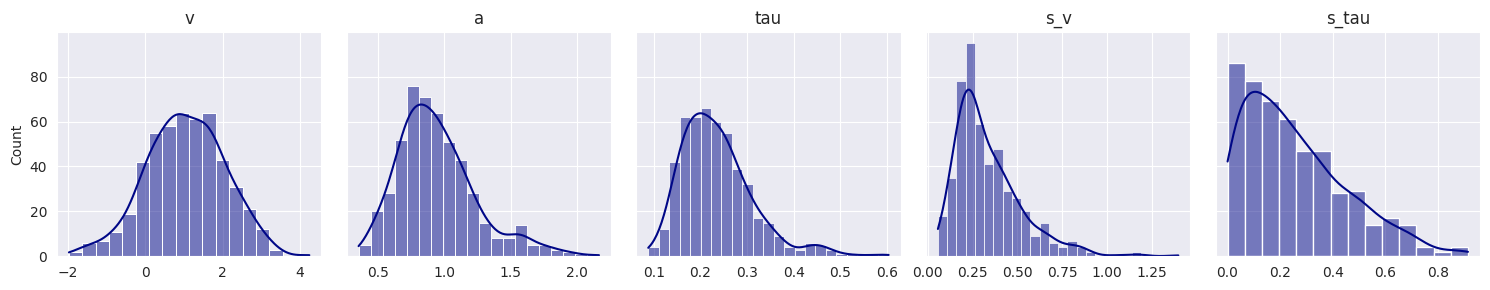

In [80]:
f = priors(ddm_log_priors)

### Visualize simulated RTs

In [6]:
from simulators.benchmarks.ddms.ddm import DDM
from simulators import NestedModelFamily

In [109]:
ddm_log_priors = {
    "v":    {"intercept": lambda: np.random.normal(1., 1.),
             "slope": lambda: 0.0},
    "a":    {"intercept": lambda: np.random.normal(-0.1, 0.3),
             "slope": lambda: 0.0},
    "tau":  {"intercept": lambda: np.random.normal(-1.5, 0.3),
             "slope": lambda: 0.0},
    "s_v":  {"intercept": lambda: np.random.normal(-1.2, 0.5),
             "slope": lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.beta(1.0, 3.0),
              "slope": lambda: 0.0}
}

In [110]:
ddm_family = NestedModelFamily(name="DDM", model=DDM(), prior_fun=ddm_log_priors)

In [111]:
samples = ddm_family.batch_sample(
    batch_size=100,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "s_v", "s_tau"},
        fixed_intrinsics={}
    ),
    num_obs=500,
    flatten_param_outputs=False
)

In [112]:
samples.keys()

dict_keys(['model_names', 'design_configs', 'design_matrices', 'param_masks', 'param_matrices', 'sim_data', 'regressor_masks', 'discrete_masks', 'num_obs', 'num_regressors', 'max_num_regressors', 'max_num_categories'])

In [113]:
for k, v in samples["sim_data"].items():
    print(k, v.shape)

rts (100, 500, 1)
choices (100, 500, 1)


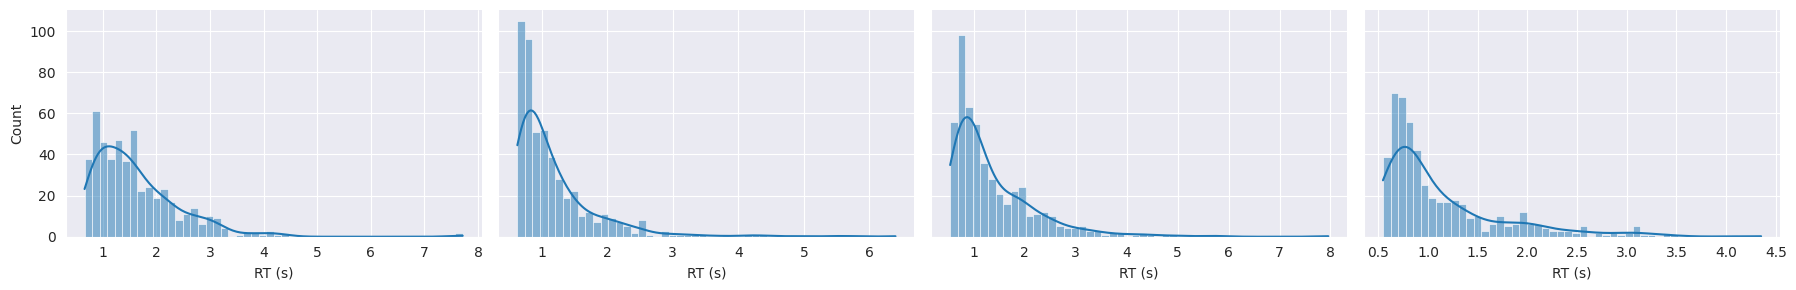

In [114]:
batch_size = 4
f, axarr = plt.subplots(1, batch_size, figsize=(18, 3), sharey=True)

for i, ax in enumerate(axarr):
    sns.histplot(samples["sim_data"]["rts"][i], ax=ax, bins=50, kde=True, color="#000787", legend=False)
    ax.set_xlabel("RT (s)")
    sns.despine(ax=ax)

f.tight_layout()

In [115]:
np.min(samples["sim_data"]["rts"])

np.float64(0.3862977623939514)

<Axes: ylabel='Count'>

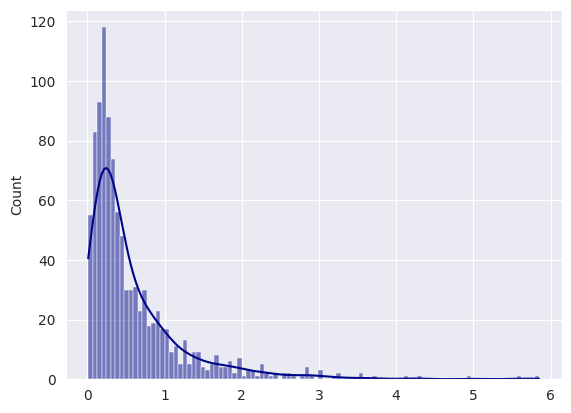

In [90]:
log_tau = np.random.normal(-1, 1, size=1000)
tau = np.exp(log_tau)
sns.histplot(tau, bins=100, color="#000787", kde=True)

In [91]:
ddm_family = NestedModelFamily(name="DDM", model=DDM(), prior_fun=ddm_log_priors)

NameError: name 'ddm_log_priors' is not defined

In [116]:
from scipy.stats import halfnorm

In [125]:
a = halfnorm.rvs(loc=0, scale=1)
a.shape

()

In [121]:
b = np.random.normal(0, 1)
b

-1.3691177639536776